# Practice Project Part 1: Australian Wildfires

**Author:** SONG XINYUE  
**Student ID:** UC627465

**AI use disclosure.** OpenAI Codex was used to assist with code drafting, debugging, and presentation. I reviewed the implementation, verified the calculations, and accept responsibility for the submitted work.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from IPython.display import display

sns.set_theme(style='whitegrid')
DATA_URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Historical_Wildfires.csv'
df = pd.read_csv(DATA_URL)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df.head()

,Region,Date,Estimated_fire_area,Mean_estimated_fire_brightness,Mean_estimated_fire_radiative_power,Mean_confidence,Std_confidence,Var_confidence,Count,Replaced,Year,Month
0,NSW,2005-01-04,8.68000,312.266667,42.400000,78.666667,2.886751,8.333333,3,R,2005,1
1,NSW,2005-01-05,16.61125,322.475000,62.362500,85.500000,8.088793,65.428571,8,R,2005,1
2,NSW,2005-01-06,5.52000,325.266667,38.400000,78.333333,3.214550,10.333333,3,R,2005,1
3,NSW,2005-01-07,6.26400,313.870000,33.800000,92.200000,7.529940,56.700000,5,R,2005,1
4,NSW,2005-01-08,5.40000,337.383333,122.533333,91.000000,7.937254,63.000000,3,R,2005,1


In [2]:
MONTH_ORDER=['January','February','March','April','May','June','July','August','September','October','November','December']
df['MonthNum']=df['Month']
print(df.shape, int(df.Year.min()), int(df.Year.max()))

(26406, 13) 2005 2020


## Task 1.1 Average estimated fire area over time

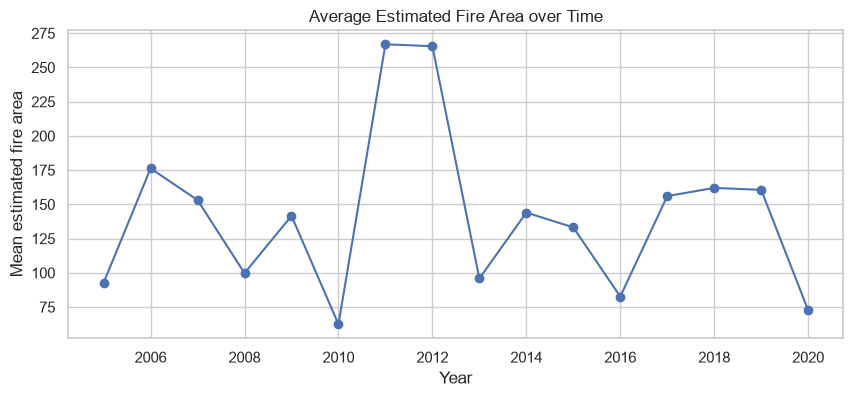

In [3]:
annual=df.groupby('Year',as_index=False)['Estimated_fire_area'].mean()
annual.plot(x='Year',y='Estimated_fire_area',marker='o',figsize=(10,4),title='Average Estimated Fire Area over Time',legend=False); plt.ylabel('Mean estimated fire area'); plt.show()

## Task 1.2 Average estimated fire area by month

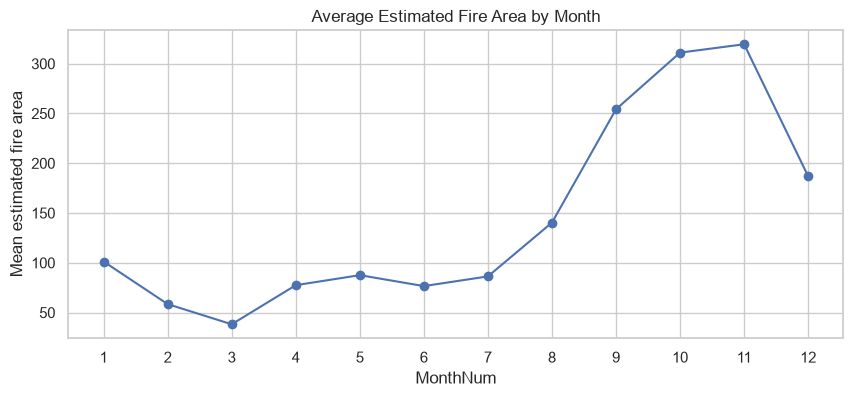

In [4]:
monthly=df.groupby('MonthNum',as_index=False)['Estimated_fire_area'].mean()
monthly.plot(x='MonthNum',y='Estimated_fire_area',marker='o',figsize=(10,4),title='Average Estimated Fire Area by Month',legend=False); plt.xticks(range(1,13)); plt.ylabel('Mean estimated fire area'); plt.show()

## Task 1.3 Mean fire brightness by region

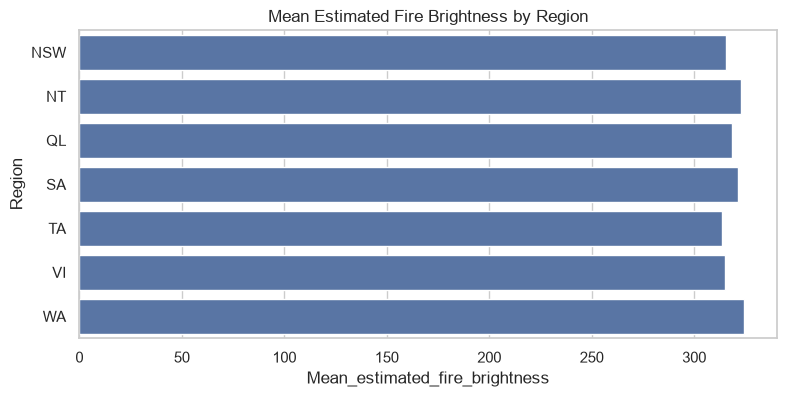

In [5]:
reg=df.groupby('Region',as_index=False)['Mean_estimated_fire_brightness'].mean()
plt.figure(figsize=(9,4)); sns.barplot(data=reg,x='Mean_estimated_fire_brightness',y='Region'); plt.title('Mean Estimated Fire Brightness by Region'); plt.show()

## Task 1.4 Pixel counts by region

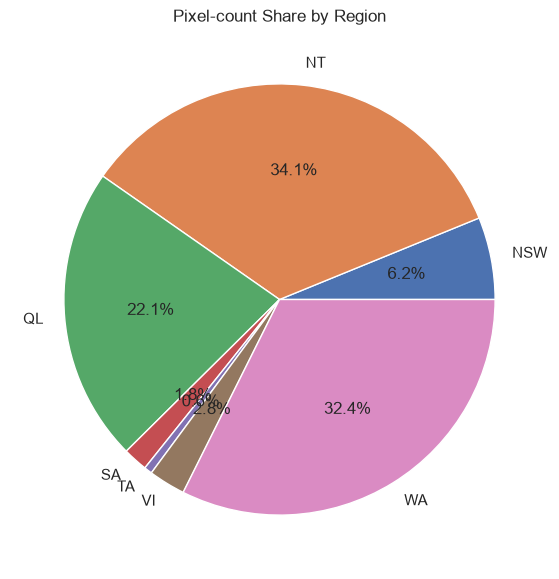

In [6]:
pix=df.groupby('Region')['Count'].sum()
pix.plot.pie(autopct='%1.1f%%',figsize=(7,7),title='Pixel-count Share by Region'); plt.ylabel(''); plt.show()

## Task 1.5 Customized pixel-count pie

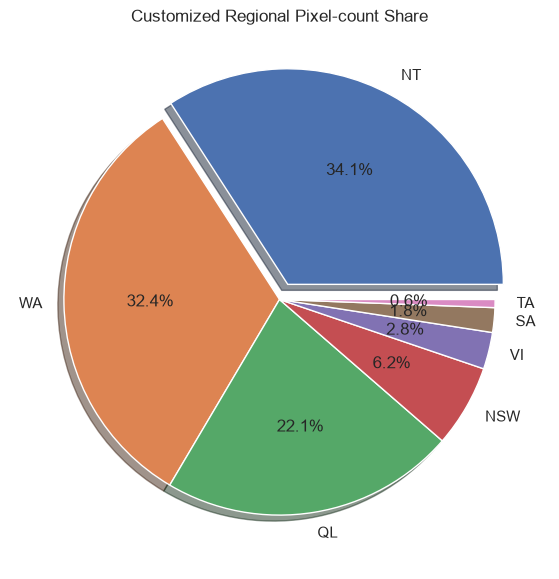

In [7]:
pix.sort_values(ascending=False).plot.pie(autopct='%1.1f%%',explode=[.08]+[0]*(len(pix)-1),shadow=True,figsize=(7,7),title='Customized Regional Pixel-count Share'); plt.ylabel(''); plt.show()

## Task 1.6 Distribution of mean fire brightness

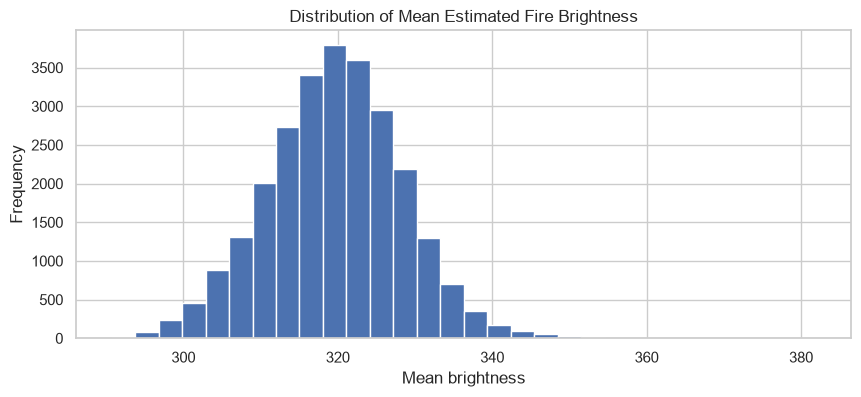

In [8]:
plt.figure(figsize=(10,4)); plt.hist(df['Mean_estimated_fire_brightness'],bins=30,edgecolor='white'); plt.title('Distribution of Mean Estimated Fire Brightness'); plt.xlabel('Mean brightness'); plt.ylabel('Frequency'); plt.show()

## Task 1.7 Brightness distribution by region

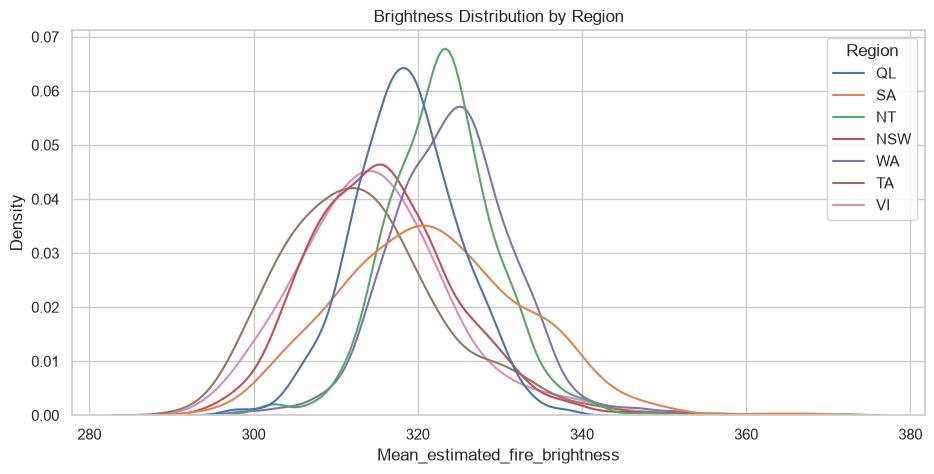

In [9]:
sample=df.sample(min(7000,len(df)),random_state=42)
plt.figure(figsize=(11,5)); sns.kdeplot(data=sample,x='Mean_estimated_fire_brightness',hue='Region',common_norm=False); plt.title('Brightness Distribution by Region'); plt.show()

## Task 1.8 Radiative power versus confidence

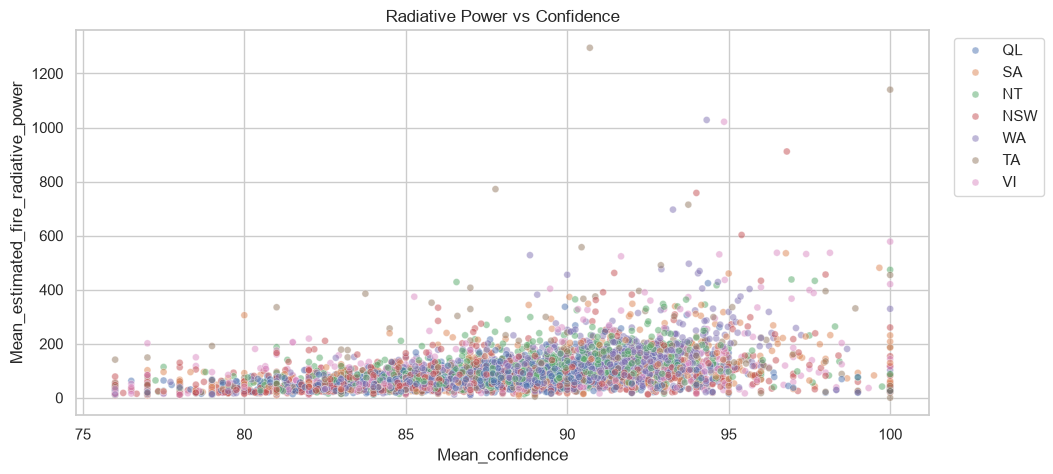

In [10]:
plt.figure(figsize=(11,5)); sns.scatterplot(data=sample,x='Mean_confidence',y='Mean_estimated_fire_radiative_power',hue='Region',alpha=.5,s=25); plt.title('Radiative Power vs Confidence'); plt.legend(bbox_to_anchor=(1.02,1),loc='upper left'); plt.show()

## Task 1.9 Folium map of the seven regions

In [11]:
coords={'NSW':(-31.25,146.92),'NT':(-19.49,132.55),'QL':(-22.58,144.58),'SA':(-30.00,136.21),'TA':(-42.04,146.81),'VI':(-36.98,144.55),'WA':(-25.23,121.02)}
m=folium.Map(location=[-25,134],zoom_start=4,tiles='OpenStreetMap')
for region,(lat,lon) in coords.items(): folium.Marker([lat,lon],tooltip=region,popup=f'{region} wildfire region').add_to(m)
m.save('Practice_1_9_Australia_Regions_Map.html')
m

## Conclusion

The analysis reveals clear temporal, seasonal, and regional variation in Australian wildfire activity. The dashboard in Part 2 complements these static views with region and year controls.